# Working with complicated dataset

Your name: Shannon Lo?

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

with pd.io.common.get_handle(url, "r") as f:
    lines = f.handle.readlines()


fields_line = [l for l in lines if "Fields:" in l][0]
fields_line = fields_line.strip().strip('"')
columns = [col.strip() for col in fields_line.split("Fields:")[1].strip().split(",")]
columns = [col for col in columns if col]


df = pd.read_csv(url, comment="#", header=None, usecols=range(len(columns)), names=columns)


df = df.drop(columns=["query acc.ver"])
df = df.set_index("subject acc.ver")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,"publications"""
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41


### Question 2
What is the average number of publications?

In [19]:

average_pubs = df["publications"].mean()

print(f"Average Number of Publications: {average_pubs}")

Average Number of Publications: 26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [22]:
df["bonds"] = pd.to_numeric(df["bonds"].astype(str).str.replace(",", "").str.strip())

bonds_total = df[df["bonds"] > 15000]
print(bonds_total.index.tolist())

['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1', '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1', 'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1', 'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1', 'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1', 'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1', 'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1', 'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1', 'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1']


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

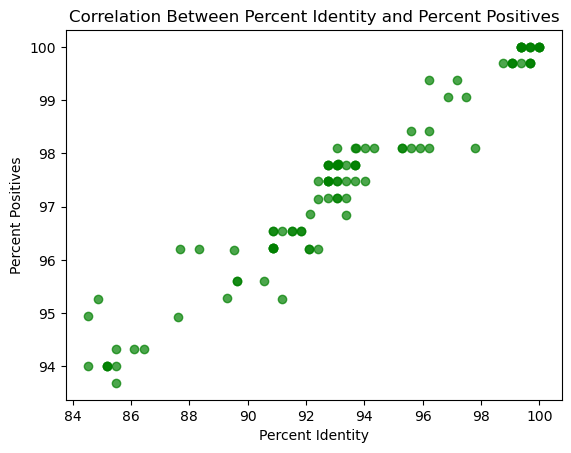

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df["% identity"], df["% positives"], alpha=0.7, color="green")
plt.xlabel("Percent Identity")
plt.ylabel("Percent Positives")
plt.title("Correlation Between Percent Identity and Percent Positives")

plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [44]:
protein_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(protein_url)
print(protein_df.columns.tolist())
print(protein_df.head())


['Unnamed: 0', 'Protein', 'Source']
   Unnamed: 0         Protein   Source
0           0     NP_904328.1   RefSeq
1           2     YP_220563.1  GenPept
2          12  YP_002791042.1  GenPept
3          13  YP_001686698.1  GenPept
4          21  YP_009112408.1  GenPept


In [46]:

df = df.reset_index()
df = df.merge(protein_df[["Protein", "Source"]], 
              left_on="subject acc.ver", 
              right_on="Protein", 
              how="left"
              )


df = df.drop(columns=["Protein"])
df = df.set_index("subject acc.ver")


df = df.rename(columns={"Source": "Protein source"})
df["Protein source"] = df["Protein source"].fillna("NA")

df.head()

,index,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source,Protein source
subject acc.ver,,,,,,,,,,,,,,,,
NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NA,NA
NP_904328.1,1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487.0,9.0,RefSeq,RefSeq
AGK29621.1,2,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947.0,47.0,NA,NA
YP_220563.1,3,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106.0,13.0,GenPept,GenPept
ACM24502.1,4,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319.0,41.0,NA,NA
